# Trabalho Prático 02 — Clusterização com K-means

**Disciplina:** GCC 128 — Inteligência Artificial  
**Alunos:** Gilmar Silva de Medeiros Filho e Samuel de Oliveira Vanoni  

## Objetivo

Desenvolver uma implementação do algoritmo K-means a partir do zero, sem o uso de bibliotecas especializadas, e compará-la com a implementação disponível na biblioteca *Scikit-learn*, utilizando a base de dados Iris.

A avaliação será realizada com base na métrica *Silhouette Score*, além da análise de desempenho computacional (tempo de execução).

## 1. Configuração e Carregamento dos Dados

Importação das bibliotecas necessárias e carregamento da base de dados Iris.

Conforme os requisitos do trabalho, a variável alvo (`target`) foi separada do conjunto de dados, de modo a não influenciar o processo de clusterização, garantindo que o algoritmo opere exclusivamente sobre as variáveis independentes.

In [1]:
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# 1. Carregamento dos dados
iris = load_iris()
X = iris.data

# O target real (y_true) não será usado no treinamento, 
# apenas guardado para eventual análise de desempenho posterior.
y_true = iris.target 

df_iris = pd.DataFrame(X, columns=iris.feature_names)
display(df_iris.head())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


## 2. Implementação do K-means

Construção do algoritmo K-means em Python puro, sem o uso de bibliotecas de *machine learning* para a implementação de sua lógica central.

A classe `KMeansHardcore` é responsável pela inicialização dos centróides, pela atribuição dos pontos aos clusters com base na distância euclidiana e pela atualização iterativa das posições dos centróides.

Os tempos de execução das etapas de ajuste (`fit`) e predição (`predict`) são medidos internamente para fins de análise de desempenho.

In [2]:
class KMeansHardcore:
    def __init__(self, n_clusters, max_iter=300, tol=1e-4, random_state=None):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state
        self.centroids = None
        self.fit_time = 0.0
        self.predict_time = 0.0

    def fit(self, X):
        start_time = time.time()
        if self.random_state:
            np.random.seed(self.random_state)
        
        # Inicialização aleatória dos centroides
        random_idx = np.random.permutation(X.shape[0])[:self.n_clusters]
        self.centroids = X[random_idx]

        for _ in range(self.max_iter):
            # Atribuição de clusters
            labels = self._assign_clusters(X)
            
            # Atualização dos centroides baseada na média dos pontos de cada cluster
            new_centroids = np.array([X[labels == k].mean(axis=0) if np.any(labels == k) else self.centroids[k] for k in range(self.n_clusters)])
            
            # Verificação de convergência
            if np.all(np.abs(new_centroids - self.centroids) <= self.tol):
                break
                
            self.centroids = new_centroids
            
        self.fit_time = time.time() - start_time
        return self

    def _assign_clusters(self, X):
        # Calcula a distância Euclidiana entre cada ponto e os centroides
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def predict(self, X):
        start_time = time.time()
        labels = self._assign_clusters(X)
        self.predict_time = time.time() - start_time
        return labels

## 3. Experimentos: K-means (k = 3 e k = 5)

Execução da implementação desenvolvida para os casos com 3 e 5 clusters.

Para cada configuração de k, o algoritmo realiza o ajuste iterativo dos centróides aos dados e atribui rótulos aos pontos com base na proximidade (distância euclidiana).

Em seguida, calcula-se o *Silhouette Score* como métrica de avaliação, a fim de quantificar a qualidade dos agrupamentos obtidos.

In [3]:
# Avaliação do modelo Hardcore
resultados_hc = {}

for k in [3, 5]:
    print(f"--- KMeans Hardcore (k={k}) ---")
    
    # Instanciação e Treinamento
    model_hc = KMeansHardcore(n_clusters=k, random_state=42)
    model_hc.fit(X)
    
    # Predição
    labels_hc = model_hc.predict(X)
    
    # Métrica de Avaliação
    score_hc = silhouette_score(X, labels_hc)
    
    # Armazenando para comparação futura
    resultados_hc[k] = {
        'silhouette': score_hc,
        'fit_time': model_hc.fit_time,
        'predict_time': model_hc.predict_time,
        'labels': labels_hc
    }
    
    print(f"Silhouette Score: {score_hc:.4f}")
    print(f"Tempo de Fit: {model_hc.fit_time:.6f} s")
    print(f"Tempo de Predict: {model_hc.predict_time:.6f} s\n")

--- KMeans Hardcore (k=3) ---
Silhouette Score: 0.5528
Tempo de Fit: 0.003873 s
Tempo de Predict: 0.000075 s

--- KMeans Hardcore (k=5) ---
Silhouette Score: 0.4931
Tempo de Fit: 0.001622 s
Tempo de Predict: 0.000077 s



## 4. Experimentos: K-means (Scikit-learn, k = 3 e k = 5)

Execução do algoritmo K-means utilizando a biblioteca *Scikit-learn*, com o objetivo de estabelecer uma referência de desempenho (*benchmark*).

Para cada configuração de k, os tempos de execução das etapas de ajuste (`fit`) e predição (`predict`) são medidos externamente, de modo a garantir comparabilidade com a implementação desenvolvida.

In [4]:
# Avaliação do modelo Sklearn
resultados_sk = {}

for k in [3, 5]:
    print(f"--- Sklearn KMeans (k={k}) ---")
    
    # Instanciação
    # n_init='auto' é o padrão nas versões recentes do sklearn
    model_sk = KMeans(n_clusters=k, random_state=42, n_init='auto')
    
    # Treinamento e medição de tempo
    start_fit = time.time()
    model_sk.fit(X)
    fit_time_sk = time.time() - start_fit
    
    # Predição e medição de tempo
    start_predict = time.time()
    labels_sk = model_sk.predict(X)
    predict_time_sk = time.time() - start_predict
    
    # Métrica de Avaliação
    score_sk = silhouette_score(X, labels_sk)
    
    # Armazenando para comparação futura
    resultados_sk[k] = {
        'silhouette': score_sk,
        'fit_time': fit_time_sk,
        'predict_time': predict_time_sk,
        'labels': labels_sk
    }
    
    print(f"Silhouette Score: {score_sk:.4f}")
    print(f"Tempo de Fit: {fit_time_sk:.6f} s")
    print(f"Tempo de Predict: {predict_time_sk:.6f} s\n")

--- Sklearn KMeans (k=3) ---
Silhouette Score: 0.5512
Tempo de Fit: 0.080587 s
Tempo de Predict: 0.000494 s

--- Sklearn KMeans (k=5) ---
Silhouette Score: 0.4931
Tempo de Fit: 0.003971 s
Tempo de Predict: 0.000412 s



## 5. Redução de Dimensionalidade com PCA

Com base nos resultados obtidos anteriormente, adotou-se k = 3 como o número de clusters.

Nesta etapa, aplica-se a Análise de Componentes Principais (PCA) para reduzir a dimensionalidade do conjunto de dados Iris para 1 e 2 componentes principais.

O objetivo é possibilitar a visualização dos clusters e das posições dos centróides nos subespaços projetados.

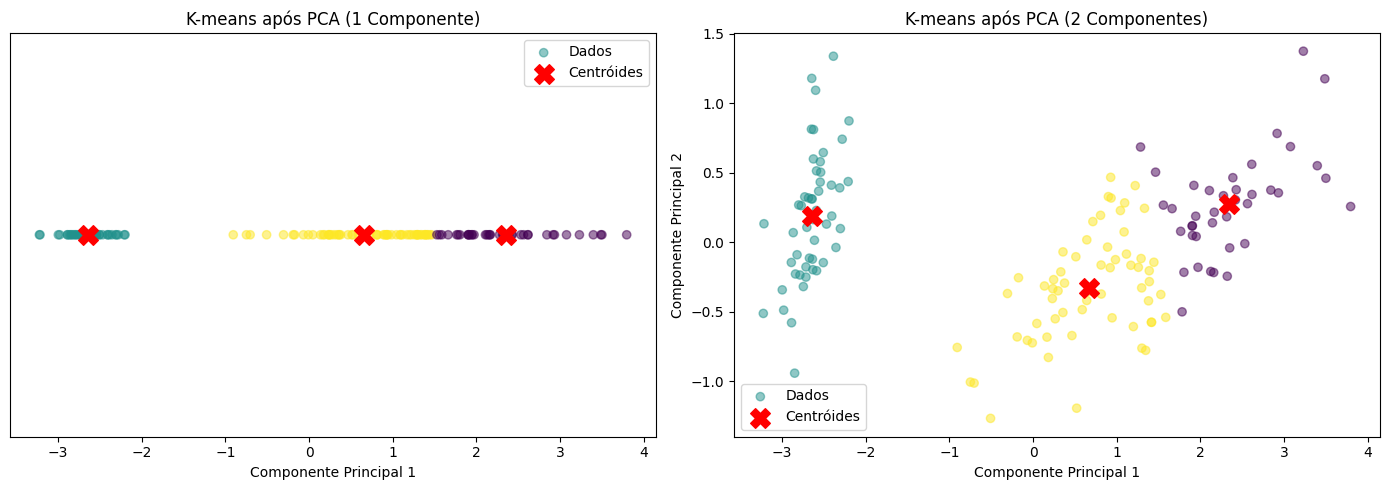

In [5]:
# Definindo o melhor k com base na métrica de Silhouette
melhor_k = 3

# Configuração da figura para exibir os dois gráficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---------------------------------------------------------
# EXPERIMENTO 1: PCA com 1 Componente
# ---------------------------------------------------------
pca_1 = PCA(n_components=1)
X_pca_1 = pca_1.fit_transform(X)

# Rodando o K-means na base reduzida
kmeans_pca_1 = KMeans(n_clusters=melhor_k, random_state=42, n_init='auto')
labels_pca_1 = kmeans_pca_1.fit_predict(X_pca_1)
centroids_pca_1 = kmeans_pca_1.cluster_centers_

# Plotagem 1D (usamos um array de zeros para o eixo Y para alinhar os pontos)
axes[0].scatter(X_pca_1, np.zeros_like(X_pca_1), c=labels_pca_1, cmap='viridis', alpha=0.5, label='Dados')
axes[0].scatter(centroids_pca_1, np.zeros_like(centroids_pca_1), c='red', marker='X', s=200, label='Centróides')
axes[0].set_title('K-means após PCA (1 Componente)')
axes[0].set_xlabel('Componente Principal 1')
axes[0].set_yticks([]) # Oculta os ticks do eixo Y pois não há variação
axes[0].legend()

# ---------------------------------------------------------
# EXPERIMENTO 2: PCA com 2 Componentes
# ---------------------------------------------------------
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X)

# Rodando o K-means na base reduzida
kmeans_pca_2 = KMeans(n_clusters=melhor_k, random_state=42, n_init='auto')
labels_pca_2 = kmeans_pca_2.fit_predict(X_pca_2)
centroids_pca_2 = kmeans_pca_2.cluster_centers_

# Plotagem 2D
axes[1].scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=labels_pca_2, cmap='viridis', alpha=0.5, label='Dados')
axes[1].scatter(centroids_pca_2[:, 0], centroids_pca_2[:, 1], c='red', marker='X', s=200, label='Centróides')
axes[1].set_title('K-means após PCA (2 Componentes)')
axes[1].set_xlabel('Componente Principal 1')
axes[1].set_ylabel('Componente Principal 2')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. Validação Externa via Matriz de Contingência (Heatmap)

Realiza-se a comparação entre os rótulos gerados pelo K-means (k = 3) e a variável alvo original (`target`) da base Iris por meio de uma matriz de contingência.

Por se tratar de um algoritmo não supervisionado, não há correspondência prévia entre os rótulos dos clusters e as classes reais; entretanto, essa correspondência não é aleatória, podendo ser analisada a posteriori.

A visualização da matriz em formato de mapa de calor permite identificar o grau de associação entre clusters e classes, evidenciando a pureza dos agrupamentos e possíveis sobreposições entre espécies.

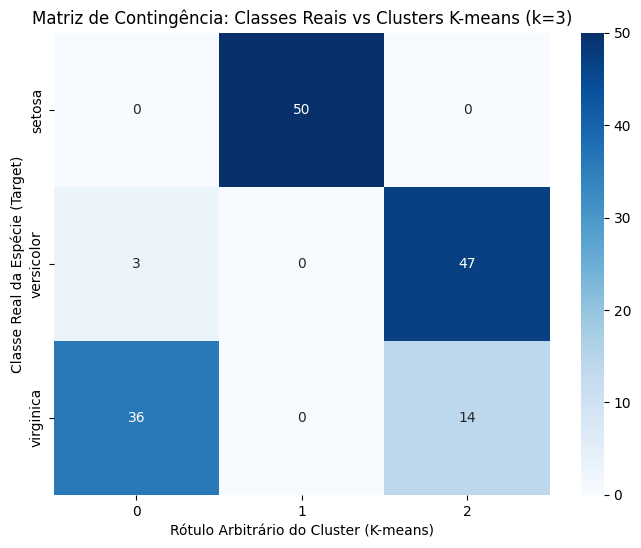

In [8]:
import seaborn as sns

# Mapeando os targets reais para os nomes das espécies
especies_reais = [iris.target_names[t] for t in y_true]
labels_k3 = resultados_sk[3]['labels']

# Criando um DataFrame para o cruzamento
df_comparacao = pd.DataFrame({'Classe Real': especies_reais, 'Cluster K-means': labels_k3})

# Gerando a matriz de contingência
matriz_contingencia = pd.crosstab(df_comparacao['Classe Real'], df_comparacao['Cluster K-means'])

# Plotagem do Mapa de Calor (Heatmap)
plt.figure(figsize=(8, 6))
sns.heatmap(matriz_contingencia, annot=True, cmap="Blues", fmt="d", cbar=True)
plt.title('Matriz de Contingência: Classes Reais vs Clusters K-means (k=3)')
plt.xlabel('Rótulo Arbitrário do Cluster (K-means)')
plt.ylabel('Classe Real da Espécie (Target)')
plt.show()